# What is the dependency on the galaxy selection?
--------

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from get_model_probabilities import *
import scienceplots
plt.style.use(["science","grid"])
from sidm_inference_on_data_and_models import infer_sidm
from scipy.stats import binned_statistic


Source redshift:1.36


In [5]:
ifilter = 'concat'
all_mag_low_cuts = np.linspace(21,24,11)
all_mag_cuts = np.linspace(28,26,11)
all_siz_cuts = np.linspace(2,3,11)

In [6]:

outfile = f"../data/100/a2744/obs_data_{ifilter}_gal_selection_bias.pkl"
obs_data = get_obs_data( ifilter, data_dir="../data/100/a2744/")

binned_data = bin_obs_data( obs_data )

fid_e1 = binned_data['e1']
fid_e2 = binned_data['e2']

e1_stacked = [fid_e1]
e2_stacked = [fid_e2]
ngalaxies = []
for iMAG_CUT in all_mag_low_cuts:
    
    new_data = obs_data.copy()    

    
    new_data = new_data[ new_data['MAG'] > iMAG_CUT]
    
    binned_data = bin_obs_data( new_data )
   
    cut_e1 = binned_data['e1']
    cut_e2 = binned_data['e2']

    e1_stacked.append( cut_e1 )
    e2_stacked.append( cut_e2 )
    ngalaxies.append(new_data.shape[0])
    
for iMAG_CUT in all_mag_cuts:
    
    new_data = obs_data.copy()    

    
    new_data = new_data[ new_data['MAG'] < iMAG_CUT]
    
    binned_data = bin_obs_data( new_data )
   
    cut_e1 = binned_data['e1']
    cut_e2 = binned_data['e2']
    
    e1_stacked.append( cut_e1 )
    e2_stacked.append( cut_e2 )
    ngalaxies.append(new_data.shape[0])
for iSIZE_CUT in all_siz_cuts:
    
    new_data = obs_data.copy()
    
    new_data = new_data[ new_data['SIZE'] > iSIZE_CUT]
    

    binned_data = bin_obs_data( new_data )
   
    cut_e1 = binned_data['e1']
    cut_e2 = binned_data['e2']
    
    e1_stacked.append( cut_e1 )
    e2_stacked.append( cut_e2 )
    ngalaxies.append(new_data.shape[0])
 
e1_stacked = np.array(e1_stacked)
e2_stacked = np.array(e2_stacked)

stacked = np.append(e1_stacked[None,:,:,:], e2_stacked[None,:,:,:], axis=0)
stacked = np.moveaxis( stacked, 0, 1)
ngalaxies = np.array(ngalaxies)

pkl.dump([{}, stacked],open(outfile,"wb"))

#RUN ALL MODELS ON THE TEST DATA
#-------------------------------
args.source_domain='a2744'
args.target_domain='a2744'

models = {}
probabilities = {}
probabilities_noise = {}

    
    
cdan_models = np.sort(glob(
    f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth"
))
all_models = []
for imodel in cdan_models:
    args.checkpoint = imodel
    this_model = create_model(args)

    model_name = f"seed_{this_model.args.seed}"
    #if target_test_accuracy[ifilter][model_name]['target_test_f1'] <0.48:
    #    continue

    all_models.append(this_model)
print(f"Found {len(all_models)} Models")
models[ifilter] = all_models
meta, data = pkl.load(open(outfile,"rb"))

#repeat 
probabilities_filt = []
probabilities_noise_filt = []

with torch.no_grad():

    for imodel in tqdm(all_models):
        outputs_dict = imodel([torch.tensor(data,dtype=torch.float32)])
        #if torch.all(torch.abs(outputs_dict['classification'][:,0] - outputs_dict['classification'][0,0])  < 0.01):
        #   continue
        probabilities_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[0,0]) 
        probabilities_noise_filt.append(torch.softmax( outputs_dict['classification'], dim=1 )[1:,0])


probabilities_filt = torch.tensor( probabilities_filt).detach().numpy()
probabilities_noise_filt =  torch.stack( probabilities_noise_filt).detach().numpy()


probabilities[ifilter] = probabilities_filt
probabilities_noise[ifilter] = probabilities_noise_filt
pkl.dump([models, probabilities, probabilities_noise], open("pickles/model_on_data_galaxy_selection.pkl","wb"))

REMOVING 108 GALAXIES


NameError: name 'sus' is not defined

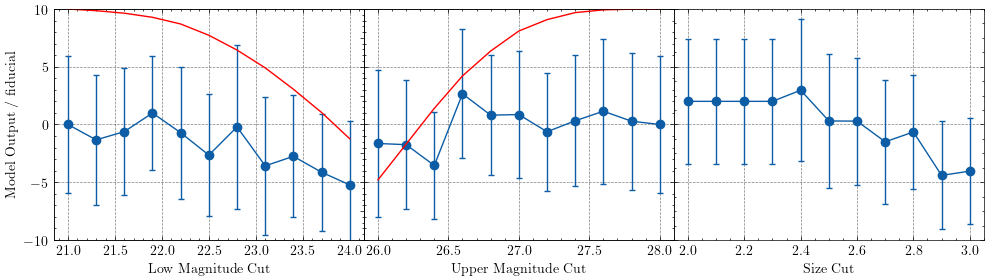

In [12]:
models, probabilities, probabilities_noise, ngalaxies = pkl.load( open("pickles/model_on_data_galaxy_selection.pkl","rb"))

ifilter = 'concat'
all_mag_low_cuts = np.linspace(21,24,11)
all_mag_cuts = np.linspace(28,26,11)
all_siz_cuts = np.linspace(2,3,11)


fig,ax = plt.subplots(1,3,figsize=(12,3))
ifilter='concat'
fig.subplots_adjust(wspace=0)
start_index = 0
end_index = all_mag_low_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 

fiducial = 1-np.mean(probabilities_noise[ifilter][:,0],axis=0) 


ax[0].errorbar( all_mag_low_cuts, ((1-means)/fiducial-1)*100, errors/fiducial*100., capsize=2, fmt='o-')
ngal = ax[0].twinx()
ngal.plot( all_mag_low_cuts, ngalaxies[start_index:end_index]/ngalaxies[0], 'r-')
ax[0].set_xlabel("Low Magnitude Cut")  
ax[0].set_ylim(-10,10)
ngal.set_ylim(0.6,1.)
ax[0].set_ylabel("Model Output / fiducial")
ngal.set_yticklabels([])
ngal.grid(False)

start_index += all_mag_low_cuts.shape[0]
end_index += all_mag_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 

ax[1].errorbar( all_mag_cuts, ((1-means)/fiducial-1)*100, errors/fiducial*100., capsize=2, fmt='o-')
ngal = ax[1].twinx()
ngal.plot( all_mag_cuts, ngalaxies[start_index:end_index]/ngalaxies[0], 'r-')
ax[1].set_xlabel("Upper Magnitude Cut")  
ax[1].set_ylim(-10,10)
ngal.set_ylim(0.6,1.)
ngal.set_yticklabels([])
ax[1].set_yticklabels([])
ngal.grid(False)


start_index += all_mag_cuts.shape[0]
end_index += all_siz_cuts.shape[0]
means =  np.mean(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 
errors =  np.std(probabilities_noise[ifilter][:,start_index:end_index],axis=0) 

ax[2].errorbar( all_siz_cuts, ((1-means)/fiducial-1)*100, errors/fiducial*100., capsize=2, fmt='o-')
ax[2].set_xlabel("Size Cut")
ax[2].set_yticklabels([])

'''
ngal = ax[2].twinx()
ngal.plot( all_siz_cuts, ngalaxies[start_index:end_index]/ngalaxies[0], 'r-')
ax[2].set_ylim(-10,10)
ngal.set_ylim(0.6,1.)
ngal.set_ylabel("N Galaxies / fiducial")
'''
ngal.grid(False)
for a in ax:
    a.yaxis.set_major_locator(LinearLocator(5))

# after creating each twin axis
ngal.yaxis.set_major_locator(LinearLocator(5))

# Now find the new thresholds for blocking out different amounts of galaxies
------
No - decide not to do as its not accurate - i can just say that above 2.6 is 30% above the PSF and therefore fine

In [184]:
imonte=40
zs = {
'f115w':1.6,
'f150w':1.65,
'concat':1.65
}
#target_test_acc = pkl.load(open("pickles/target_test_accuracy.pkl","rb"))

ngal_list = ngalaxies[11:]/ngalaxies[0]

for ifilter in ['concat']:
    already_done = 0
    output_name = f"pickles/all_models_{ifilter}_ngal_dep_results.pkl"
    obs_data = get_obs_data(ifilter, data_dir="../data/a2744/", photoz=True)
    delta_ra, delta_dec = ra_dec_to_simulation_image_pos( obs_data )

    fid_n_z = binned_statistic_2d(
            delta_ra, delta_dec, obs_data['redshift'], 
            range=[[-image_size//2,image_size//2],
                   [-image_size//2,image_size//2]],
            statistic=np.median, bins=image_size
        ).statistic
    
    fid_n_z[ ~np.isfinite(fid_n_z) ] = 0.
    
    if os.path.isfile(output_name):
        all_results = pkl.load(open(output_name,'rb'))
    else:
        all_results = {}
            
    for iNgal in ngal_list[::-1]:
        
        if iNgal == 1:
            if already_done ==0: 
                already_done = 1
            else:
                continue
        
        all_results[f"{iNgal:0.2f}"] = {}
        
        image_size=100

        n_z = fid_n_z.copy()

        # indices where arr != 0
        valid_idx = np.argwhere( n_z != 0)
        
        
        number_to_block = int(len(valid_idx)*(1-iNgal)) 

        chosen = valid_idx[
            np.random.choice(
                len(valid_idx),
                size=number_to_block,
                replace=False
            )
        ]

       
        
        n_z[chosen[:,0], chosen[:,1]] = 0
        

        all_models =  glob(f"../models/concat/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")[:5]





        for imodel in tqdm(all_models):

            seed = imodel.split('_')[-7]

            args.jwst_filter = ifilter
            args.apply_intrinsic_ell = 1.

            zs = {
            'f115w':1.6,
            'f150w':1.65,
            'concat':1.65
            }

            domain = {
            'tgt':'darkskies_obs',
            'src':'bahamas_obs'
            }
            args.ignore_dataset = [''] # Although i ignored during training i want to see duringn testing.

            if f"seed_{seed}" not in all_results[f"{iNgal:0.2f}"].keys():

                all_results[f"{iNgal:0.2f}"][f"seed_{seed}"]  = {'src':[],'tgt':[]}

            args.unbalance = True

            for i in range(imonte):
                args.zs = n_z

                for idomain in domain.keys():

                    target_domain = domain[idomain]
                    results = get_probabilities( 
                            target_domain,
                            [imodel],
                            args,
                            quiet=True
                    )
                    del results['data_loaders']

                    all_results[f"{iNgal:0.2f}"][f"seed_{seed}"][idomain].append( results )

            pkl.dump(all_results, open(output_name,"wb"))


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [2:48:18<00:00, 2019.72s/it]


In [11]:
output_name = f"pickles/all_models_{ifilter}_ngal_dep_results.pkl"

thresholds = pkl.load(open(output_name,'rb'))


tgtresults = {}
srcresults = {}

correction = 2.
for ikx, ikey in enumerate(thresholds.keys()):
    
    all_results = thresholds[ikey]
    
    


    for itgt in ['src','tgt']:
        all_thresholds = []
        for imodel in all_results.keys():

            seed = float(imodel.split('_')[1])                


            tgt = get_threshold_for_cross( 
                 all_results[imodel][itgt], 
                quiet=False)

            all_thresholds.append(tgt['thresholds'])

        all_thresholds = np.array(all_thresholds)
        means = 1-np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction
            
        if itgt == 'src':
            srcresults[ikey] = [ tgt['cross_sections'], means, errors]
        else:
            tgtresults[ikey] = [ tgt['cross_sections'], means, errors]
pkl.dump([srcresults,tgtresults],open("pickles/all_models_concat_ngal_dep_results.pkl","wb"))

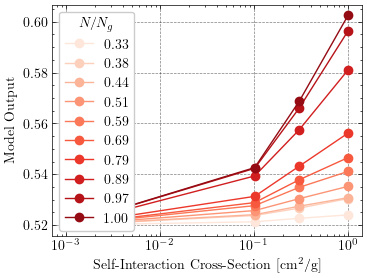

In [353]:
fig = plt.figure(figsize=(4,3))
ax = plt.gca()


color = {
        'src':colourFromRange([-1,len(tgtresults.keys())], cmap='Reds'),
        'tgt':colourFromRange([-1,len(tgtresults.keys())], cmap='Blues')
    }

for irx, iresult in enumerate(tgtresults.keys()):
    ax.plot(
        srcresults[iresult][0]+1e-3,
        (srcresults[iresult][1]-srcresults[iresult][1][0])*2.5+ 0.52,
        'o-',label=f"{iresult}", color=color['src'][irx])
    
    
    #ax.errorbar(
    #    srcresults[iresult][0],
    #    srcresults[iresult][1]-srcresults[iresult][1][0] + srcresults['1.00'][1][0],
    #    srcresults[iresult][2], fmt='o', capsize=2)
ax.set_xlabel("Self-Interaction Cross-Section [cm$^2$/g]")
ax.set_ylabel("Model Output")
ax.set_xscale('log')
ax.legend(title='$N/N_{g}$',loc=2)
fig.align_xlabels()

# Cluster Member Impact
-----------
What is the impat of cluster members? 
- Do tests with cluster members
- Make cuts on the catalogue - show that the results dont budge

### First on the results

In [323]:

ifilter = 'concat'

all_models = glob(f"../models/{ifilter}/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")[:5]
imonte=20


output_name = f"pickles/cluster_contamination_{ifilter}_test.pkl"

if os.path.isfile( output_name ):
    all_results = pkl.load(open(output_name,"rb"))
else:
    all_results = {}

domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}
args.jwst_filter = 'concat'
args.apply_intrinsic_ell = 1.
zs = {
'concat':1.65
}
args.zs = zs['concat']


args.ignore_dataset = [''] # Althopiugh i ignored during training i want to see duringn testing.

args.unbalance = False
contaminant_list = np.linspace(0,0.2,6)
for cluster_contamination in contaminant_list:
    
    if cluster_contamination not in all_results.keys():
        all_results[cluster_contamination] = {}
    
    args.cluster_member_contamination = cluster_contamination
    
    for imodel in tqdm(all_models):

        seed = imodel.split('_')[-7]

        print(seed)

        if f"seed_{seed}" not in all_results[cluster_contamination].keys():
            all_results[cluster_contamination][f"seed_{seed}"]  = {'src':[],'tgt':[]}
        


        ndone = len(all_results[cluster_contamination][f"seed_{seed}"]['src'])
        
        for i in range(ndone,imonte):
            for idomain in domain.keys():

                target_domain = domain[idomain]
                results = get_probabilities( 
                        target_domain,
                        [imodel],
                        args,
                        quiet=True
                )
                del results['data_loaders']

                all_results[cluster_contamination][f"seed_{seed}"][idomain].append( results )

    pkl.dump(all_results, open(output_name,"wb"))


  0%|                                                     | 0/5 [00:00<?, ?it/s]

2


 20%|█████████                                    | 1/5 [00:43<02:52, 43.22s/it]

12


 40%|██████████████████                           | 2/5 [01:25<02:08, 42.80s/it]

...

 60%|███████████████████████████                  | 3/5 [02:20<01:33, 46.89s/it]

29


 80%|████████████████████████████████████         | 4/5 [03:07<00:46, 46.87s/it]

24


100%|█████████████████████████████████████████████| 5/5 [03:54<00:00, 46.89s/it]


In [350]:
obs_data = get_obs_data( 'concat', data_dir="../data/100/a2744/")
binned_data = bin_obs_data( obs_data )
fid_e1 = binned_data['e1']
fid_e2 = binned_data['e2']
ngal = binned_data['ngal']

REMOVING 108 GALAXIES


In [351]:
obs_meta, obs_data = pkl.load(open(f"../data/100/a2744/obs_data_concat.pkl","rb"))
obs_cat = combine_catalogues(
    "../data/100/a2744/a2744_f115w_filtered.fits",
    "../data/100/a2744/a2744_f150w_filtered.fits"
)


if np.max(obs_cat['x']) > 1000:
    ra,dec = ra_dec_to_simulation_image_pos( obs_cat)
    obs_cat['x'] = ra
    obs_cat['y'] = dec
image_size  = 100
obs_kappa_e, obs_kappa_b = get_kappa(
    obs_cat, smooth=1.5, extent=[
                    -image_size//2,image_size//2,-image_size//2,image_size//2
                ]
)


9737 galaxies in common
1889 extra galaxies in cat_a
4107 extra galaxies in cat_b
15733 total galaxies


Python(8206) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(8207) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


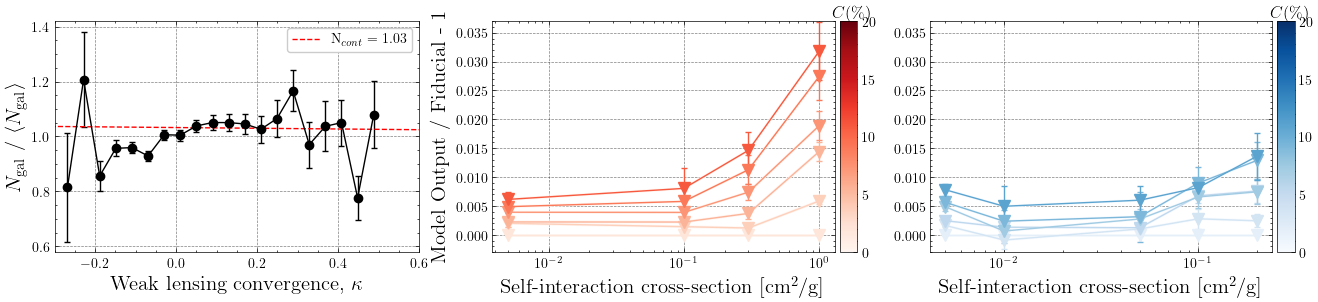

In [370]:
fig, axarr = plt.subplots(1,3,figsize=(16,3))


kappa_filtered = obs_kappa_e[ ngal > 0 ].flatten()
ngal_filtered = ngal[ ngal > 0 ].flatten()


bins = 20
y,x,n = binned_statistic( kappa_filtered, ngal_filtered, bins=bins, statistic=np.mean )
stdy,x,n = binned_statistic( kappa_filtered, ngal_filtered, bins=bins, statistic=np.std )
cy,x,n = binned_statistic( kappa_filtered, ngal_filtered, bins=bins, statistic='count')

xc = (x[1:]+x[:-1])/2.
fractional_change = y/np.mean(ngal_filtered)
fraction_err = stdy/np.sqrt(cy)/np.mean(ngal_filtered)
ax= axarr[0]
ax.errorbar(xc,fractional_change,fraction_err, capsize=2, fmt='o-',color='k')


def lin_func( x, a, b):
    return a + x*b

popt, pope = curve_fit(
    lin_func, xc[ xc>0], fractional_change[xc>0],sigma=fraction_err[xc>0]
)

ax.plot( np.array([-1,1]), lin_func(np.array([-1,1]), *popt),'r--',label=f'N$_{{cont}}={popt[0]:0.2f}$')
ax.set_xlim(-0.3,0.6)
ax.set_xlabel("Weak lensing convergence, $\kappa$", fontsize=15)
ax.set_ylabel("$N_{\\rm gal}$ / $\langle N_{\\rm gal}\\rangle$", fontsize=15)
ax.legend()

config='baha2dark'
filter_list  = ['concat']
cdm = 5e-3



domain = {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
}


output_name = f"pickles/cluster_contamination_{ifilter}_test.pkl"

all_tests = pkl.load(open(output_name,'rb'))



color = {
        'src':colourFromRange([-1,len(all_tests.keys())], cmap='Reds'),
        'tgt':colourFromRange([-1,len(all_tests.keys())], cmap='Blues')
    }

fid =  all_tests[0.0]

contaminant_list = np.linspace(0,0.2,6)

for izs, icontamination in enumerate(contaminant_list):
   
    
    all_results = all_tests[icontamination]


    

    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []
        ax = axarr[itgt+1]
        for imodel in all_results.keys():
            
            seed = float(imodel.split('_')[1])
  
            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)

            ref = get_threshold_for_cross( 
                fid[imodel][target], 
                mass_cut=None, 
                dataset=domain[target].split('_')[0],
                quiet=False)
            
            all_thresholds.append(ref['thresholds']/tgt['thresholds']-1)
            
        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / np.sqrt(all_thresholds.shape[0]) 
        




        tgt['cross_sections'][0] += cdm
        ax.errorbar( tgt['cross_sections'], 
                    means,
                    errors,
                    fmt='-v', label=f"$c$={icontamination}", 
                    capsize=2,
                    markersize=8, color=color[target][izs])
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]", fontsize=15)
        #ax.legend(loc=3, ncols=2)
        if itgt == 0:
            ax.set_ylabel("Model Output / Fiducial - 1", fontsize=15)
     
        points = np.column_stack([tgt['cross_sections'], means])          # shape (N, 2)
        segments = np.stack([points[:-1], points[1:]], axis=1)  # shape (N-1, 2, 2)

        lc = LineCollection(
                segments,
                cmap=color[target].cmap,
                norm=plt.Normalize(contaminant_list.min()*100, contaminant_list.max()*100),
                linewidths=2
            )

        lc.set_array(np.full(segments.shape[0], icontamination))
        im2 = ax.add_collection(lc)
        
        
        if izs == len(all_results.keys())-1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes('right', size='5%', pad=0.05)
            cbar = fig.colorbar(im2, cax=cax, orientation='vertical')
            cbar.set_ticks([0, 5, 10, 15, 20])

            ax.text(1.05,1.02,"$C(\%)$",transform=ax.transAxes,fontsize=12, ha='center')
        ax.set_ylim(-0.003,0.037)
        ax.set_xscale('log')


    

In [41]:
output_name = f"pickles/cluster_contamination_{ifilter}.pkl"

all_tests = pkl.load(open(output_name,'rb'))

In [43]:
all_tests[0] = all_tests[1][0.0]

In [42]:
all_tests[1].keys()

dict_keys([0.0, 0.2, 0.04, 0.08, 0.12, 0.16])

In [44]:
pkl.dump(all_tests, open(output_name,'wb'))